In [7]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sc

In [8]:
def Rast(x,y, dtype = 'float'):
   return np.sqrt((x[0]-x[np.size(x)-1])**2 + (y[0]-y[np.size(y)-1])**2)
   # функция подсчета длины вектора R12
def R(x,y):
     return np.sqrt(x**2 + y**2)

In [167]:
lambda_ = 800e-9   # длина волны, м
z = 0.00005    # расстояние до экрана, м
ro = np.sqrt(0.1*lambda_*z)
# x_1 = -ro/2     # координата 1-го края отверстия
# x_2 =  ro/2     # координата 2-го края отверстия
x_1 = 0
x_2 = 100000
# x_1 = - 1.9*np.sqrt(lambda_*z/2)   
# x_2 =  1.9*np.sqrt(lambda_*z/2)    

In [173]:
x = np.linspace(-0.00004, 0.00004, 1000)
y = np.linspace(-1, 0, 1000)
I_C = np.zeros(np.size(x))
A0 = 1
for i in range(np.size(x)):
    x_P = np.linspace(x_1-x[i], x_2-x[i], 2)
    u = np.sqrt(2/(lambda_*z))*x_P
    S, C = sc.fresnel(u)
    I_C[i] = (A0/np.sqrt(2)*Rast(C,S))**2
IC_x_y = np.zeros((np.size(x), np.size(y)))
for i in range(np.size(y)):
    IC_x_y[i][:] = I_C[:]

In [206]:
I_Ph = np.zeros(np.size(x))
A0 = 1
for i in range(np.size(x)):
    x_P = np.linspace(x_1-x[i], x_2-x[i], 2)
    x_O = np.linspace(-(x_2-x[i]), x_1-x[i], 2)
    u1 = np.sqrt(2/(lambda_*z))*x_P
    u2 = np.sqrt(2/(lambda_*z))*x_O
    S1, C1 = sc.fresnel(u1)
    S2, C2 = sc.fresnel(u2)
    SS1 = S1[1]-S1[0]
    CC1 = C1[1]-C1[0]
    SS2 = S2[1]-S2[0]
    CC2 = C2[1]-C2[0]
    S = SS1-SS2
    C = CC1-CC2
    I_Ph[i] = (A0/np.sqrt(2)*R(C,S))**2 #*np.exp(-(x[i]/0.000004)**2)
IPh_x_y = np.zeros((np.size(x), np.size(y)))
for i in range(np.size(y)):
    IPh_x_y[i][:] = I_Ph[:]

In [213]:
# plt.figure(dpi=125)
# plt.subplots()
# plt.plot(C,S)
# plt.plot
# plt.grid(ls=':')
# plt.xlabel('C(u)')
# plt.ylabel('S(u)')
# plt.show()
a = 0.5637769354091866

<Figure size 800x600 with 0 Axes>

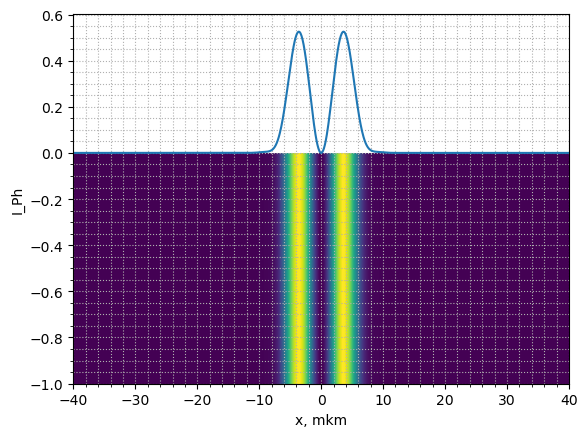

<Figure size 640x480 with 0 Axes>

In [215]:
plt.figure(dpi=125)
plt.subplots()
plt.plot(x*10**6,I_Ph) 
plt.pcolormesh(x*10**6,y,IPh_x_y)
plt.minorticks_on()
plt.grid( which='both', ls=':')
plt.xlabel('x, mkm')
plt.ylabel('I_Ph')
plt.show()
plt.savefig('фазовая ступень.pdf')

<Figure size 800x600 with 0 Axes>

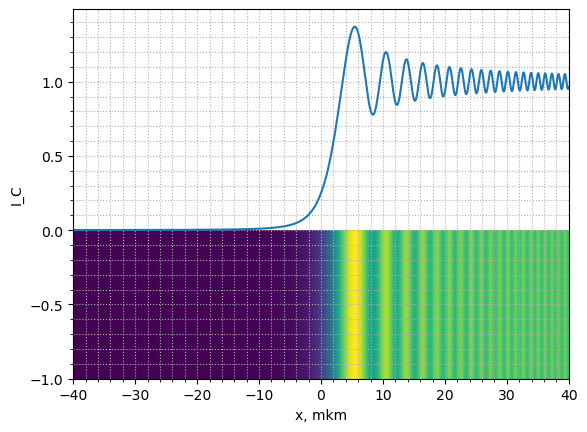

In [212]:
plt.figure(dpi=125)
plt.subplots()
plt.plot(x*10**6,I_C)
plt.pcolormesh(x*10**6,y,IC_x_y)
plt.minorticks_on()
plt.grid( which='both', ls=':')
plt.xlabel('x, mkm')
plt.ylabel('I_C')
plt.show()
# plt.savefig('фазовая ступень.pdf',dpi='figure', format = 'pdf')